# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [1]:
import numpy as np
import time
from scipy.linalg import hilbert, lu, solve_triangular

# ------------------------- Metody rozwiązywania Ax = b -------------------------

def solve_inv(A, b):
    """Jawna odwrotność macierzy A."""
    return np.linalg.inv(A) @ b

def solve_lu_inv(A, b):
    """Rozkład LU + odwrotności L i U.  A = P L U  ->  x = U^{-1} L^{-1} P^T b."""
    P, L, U = lu(A)
    return np.linalg.inv(U) @ np.linalg.inv(L) @ (P.T @ b)

def solve_lu_tri(A, b):
    """Rozkład LU + podstawianie (solve_triangular)."""
    P, L, U = lu(A)
    y = solve_triangular(L, P.T @ b, lower=True)   # L y = P^T b  (w przód)
    return solve_triangular(U, y, lower=False)      # U x = y      (wstecz)

def solve_qr_inv(A, b):
    """Rozkład QR + odwrotności Q i R.  A = Q R, Q^{-1}=Q^T  ->  x = R^{-1} Q^T b."""
    Q, R = np.linalg.qr(A)
    return np.linalg.inv(R) @ (Q.T @ b)

def solve_qr_tri(A, b):
    """Rozkład QR + odwrotność Q i podstawianie wstecz."""
    Q, R = np.linalg.qr(A)
    return solve_triangular(R, Q.T @ b, lower=False)

def gauss_seidel(A, b, tol=1e-10, max_iter=500):
    """Metoda iteracyjna Gaussa-Seidela (z poprzedniego ćwiczenia)."""
    n = len(b)
    L = np.tril(A)
    U = A - L
    L_inv = np.linalg.inv(L)
    x = np.zeros(n)
    for _ in range(max_iter):
        x = L_inv @ (b - U @ x)
        if np.linalg.norm(b - A @ x) < tol:
            break
    return x

def solve_numpy(A, b):
    """numpy.linalg.solve."""
    return np.linalg.solve(A, b)

methods = {
    'inv(A)': solve_inv,
    'LU (odwr. L,U)': solve_lu_inv,
    'LU (podstawianie)': solve_lu_tri,
    'QR (odwr. R)': solve_qr_inv,
    'QR (podstawianie)': solve_qr_tri,
    'Gauss-Seidel': gauss_seidel,
    'np.linalg.solve': solve_numpy,
}

# ------------------------- Definicja układów -------------------------
# Uwaga: macierz 1000000x1000000 to 10^12 elementów (~8 TB pamięci w float64),
# więc jest fizycznie niewykonalna. Ograniczamy się do 15 (Hilbert), 100 i 1000.
np.random.seed(0)
cases = {'Hilbert 15x15': (hilbert(15), np.random.rand(15))}
for n in [100, 1000]:
    cases[f'Losowa {n}x{n}'] = (np.random.rand(n, n) * 100.0, np.random.rand(n))

# ------------------------- 1 + 3. Uwarunkowanie i residua -------------------------
print('=== Współczynnik uwarunkowania i normy residuów ||b - Ax|| ===\n')
with np.errstate(all='ignore'):
    for name, (A, b) in cases.items():
        print(f'--- {name} | cond(A) = {np.linalg.cond(A):.3e} ---')
        for mname, m in methods.items():
            x = m(A, b)
            res = np.linalg.norm(b - A @ x)
            print(f'  {mname:20s} ||res|| = {res:.3e}')
        print()


=== Współczynnik uwarunkowania i normy residuów ||b - Ax|| ===

--- Hilbert 15x15 | cond(A) = 3.366e+17 ---
  inv(A)               ||res|| = 2.666e+02
  LU (odwr. L,U)       ||res|| = 1.756e+02
  LU (podstawianie)    ||res|| = 6.986e+01
  QR (odwr. R)         ||res|| = 1.939e+00
  QR (podstawianie)    ||res|| = 1.103e+00
  Gauss-Seidel         ||res|| = 1.161e+00
  np.linalg.solve      ||res|| = 8.833e+01

--- Losowa 100x100 | cond(A) = 6.967e+03 ---
  inv(A)               ||res|| = 2.637e-13


  LU (odwr. L,U)       ||res|| = 1.285e-13
  LU (podstawianie)    ||res|| = 9.993e-14
  QR (odwr. R)         ||res|| = 5.863e-14
  QR (podstawianie)    ||res|| = 6.274e-14


  Gauss-Seidel         ||res|| = nan
  np.linalg.solve      ||res|| = 8.777e-14



--- Losowa 1000x1000 | cond(A) = 1.247e+05 ---


  inv(A)               ||res|| = 2.392e-11


  LU (odwr. L,U)       ||res|| = 1.375e-11


  LU (podstawianie)    ||res|| = 3.980e-12


  QR (odwr. R)         ||res|| = 4.377e-13
  QR (podstawianie)    ||res|| = 3.863e-13


  Gauss-Seidel         ||res|| = nan
  np.linalg.solve      ||res|| = 2.770e-12



In [2]:
# ------------------------- 4. Pomiar wydajności (czas wykonania) -------------------------
# Liczbę powtórzeń dobieramy do rozmiaru macierzy, by pomiar trwał rozsądnie.
repeats = {'Hilbert 15x15': 1000, 'Losowa 100x100': 200, 'Losowa 1000x1000': 5}

print('=== Średni czas wykonania [ms] ===\n')
with np.errstate(all='ignore'):
    for name, (A, b) in cases.items():
        reps = repeats[name]
        print(f'--- {name} (uśrednione z {reps} powtórzeń) ---')
        for mname, m in methods.items():
            t0 = time.perf_counter()
            for _ in range(reps):
                m(A, b)
            dt = (time.perf_counter() - t0) / reps * 1e3
            print(f'  {mname:20s} {dt:10.4f} ms')
        print()


=== Średni czas wykonania [ms] ===

--- Hilbert 15x15 (uśrednione z 1000 powtórzeń) ---
  inv(A)                   0.0073 ms
  LU (odwr. L,U)           0.0355 ms
  LU (podstawianie)        0.0348 ms
  QR (odwr. R)             0.0251 ms
  QR (podstawianie)        0.0277 ms


  Gauss-Seidel             2.6324 ms
  np.linalg.solve          0.0054 ms

--- Losowa 100x100 (uśrednione z 200 powtórzeń) ---


  inv(A)                   8.3773 ms


  LU (odwr. L,U)          11.6342 ms
  LU (podstawianie)        0.2065 ms


  QR (odwr. R)             9.7278 ms
  QR (podstawianie)        0.7326 ms


...

  LU (odwr. L,U)         760.6451 ms


  LU (podstawianie)      103.4390 ms


  QR (odwr. R)           278.2567 ms


  QR (podstawianie)       65.1162 ms


  Gauss-Seidel           322.9549 ms
  np.linalg.solve         37.2506 ms



**Wnioski (Zadanie 1):**

- **Uwarunkowanie:** macierz Hilberta jest skrajnie źle uwarunkowana ($cond \approx 10^{17}$), więc nawet najlepsze metody dają duże residua — utracone zostają niemal wszystkie cyfry znaczące. Macierze losowe $[0,100]$ są dobrze uwarunkowane ($cond \sim 10^{3}$–$10^{5}$), więc residua są rzędu błędu maszynowego.
- **Dokładność:** dla macierzy źle uwarunkowanej (Hilbert) najdokładniejszy jest **rozkład QR** — jest numerycznie stabilny, bo macierz $Q$ jest ortogonalna i nie zwiększa współczynnika uwarunkowania. Jawna odwrotność wypada najgorzej. Dla macierzy dobrze uwarunkowanych wszystkie metody bezpośrednie są porównywalne (~$10^{-13}$).
- **Metoda iteracyjna:** Gauss-Seidel **rozbiega się** (`nan`) dla macierzy losowych, ponieważ nie są one przekątniowo dominujące — to oczekiwane zachowanie, metody iteracyjne wymagają spełnienia warunku zbieżności.
- **Wydajność:** najszybsza jest `np.linalg.solve` oraz LU/QR z podstawianiem trójkątnym. Warianty z jawną odwrotnością są wolniejsze (odwracanie macierzy jest droższe niż podstawianie) i mniej dokładne — w praktyce **nigdy nie liczymy jawnej odwrotności** do rozwiązania układu.


# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.

Pierwsza funkcja:  f(0.43) = 2.360605
Druga funkcja:    f2(0.25) = -0.210337


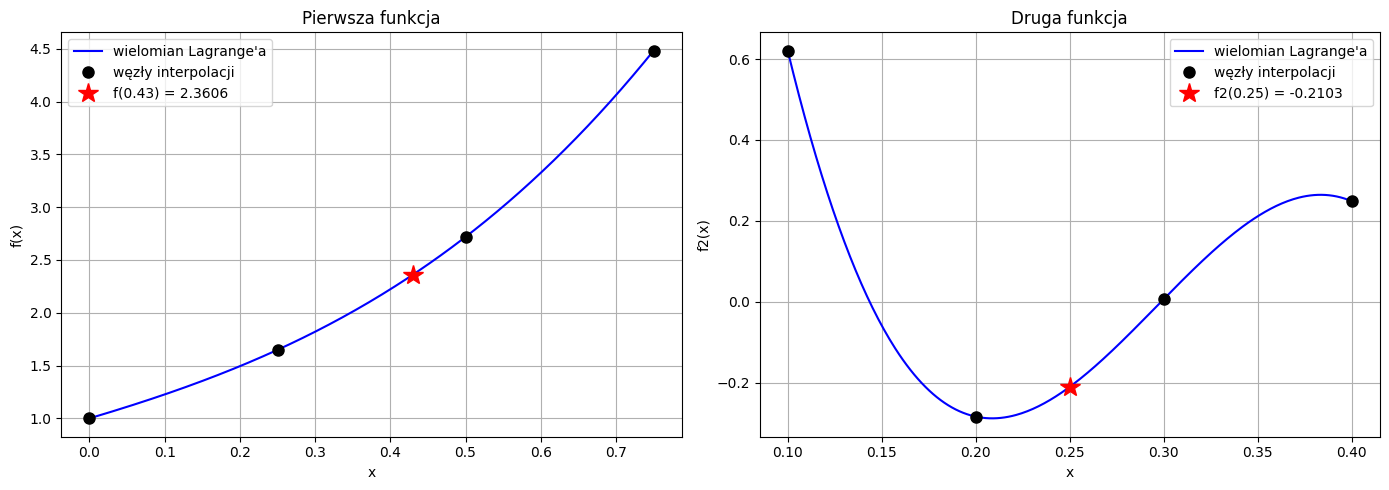

In [3]:
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# --- Pierwsza funkcja ---
x1 = np.array([0.0, 0.25, 0.5, 0.75])
y1 = np.array([1.0, 1.64872, 2.71828, 4.48169])
L1 = lagrange(x1, y1)
print(f'Pierwsza funkcja:  f(0.43) = {L1(0.43):.6f}')

# --- Druga funkcja ---
x2 = np.array([0.1, 0.2, 0.3, 0.4])
y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])
L2 = lagrange(x2, y2)
print(f'Druga funkcja:    f2(0.25) = {L2(0.25):.6f}')

# --- Wykresy ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xx1 = np.linspace(x1.min(), x1.max(), 300)
axes[0].plot(xx1, L1(xx1), 'b-', label='wielomian Lagrange\'a')
axes[0].plot(x1, y1, 'ko', markersize=8, label='węzły interpolacji')
axes[0].plot(0.43, L1(0.43), 'r*', markersize=15, label=f'f(0.43) = {L1(0.43):.4f}')
axes[0].set_title('Pierwsza funkcja')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].legend(); axes[0].grid()

xx2 = np.linspace(x2.min(), x2.max(), 300)
axes[1].plot(xx2, L2(xx2), 'b-', label='wielomian Lagrange\'a')
axes[1].plot(x2, y2, 'ko', markersize=8, label='węzły interpolacji')
axes[1].plot(0.25, L2(0.25), 'r*', markersize=15, label=f'f2(0.25) = {L2(0.25):.4f}')
axes[1].set_title('Druga funkcja')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f2(x)')
axes[1].legend(); axes[1].grid()

plt.tight_layout()
plt.show()


***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?

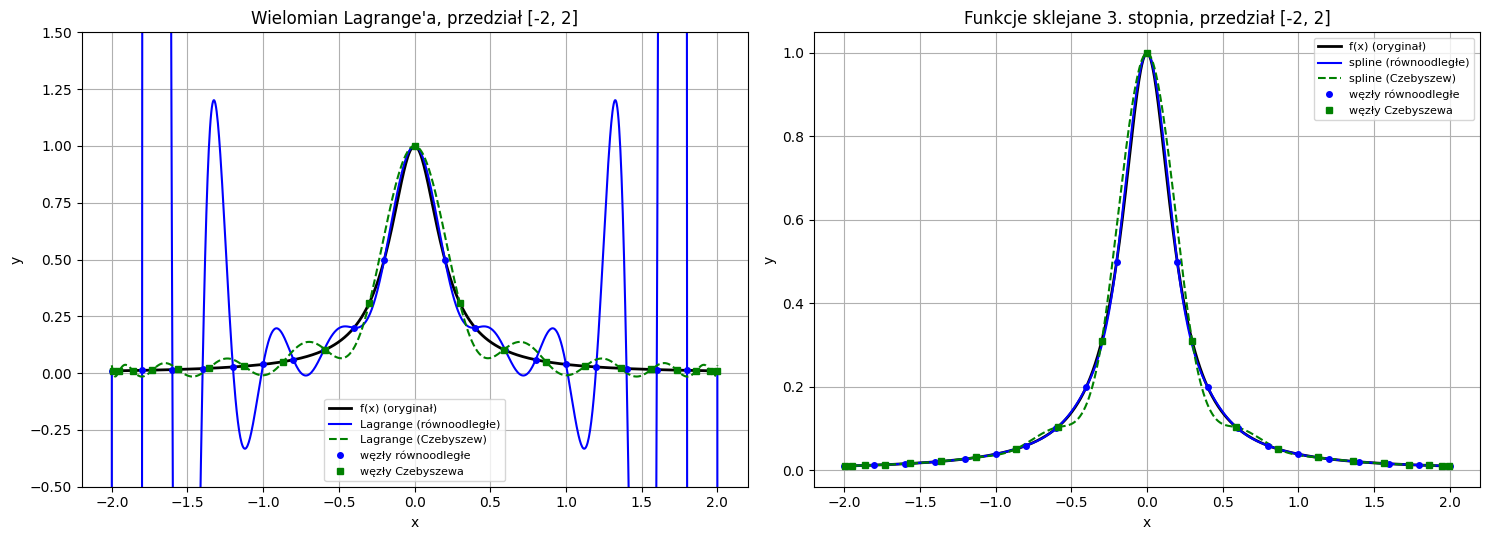

Przedział [-2, 2] — maksymalny błąd interpolacji:
  Lagrange równoodległe : 5.382e+02
  Lagrange Czebyszew    : 1.210e-01
  Spline   równoodległe : 2.197e-02
  Spline   Czebyszew    : 9.641e-02



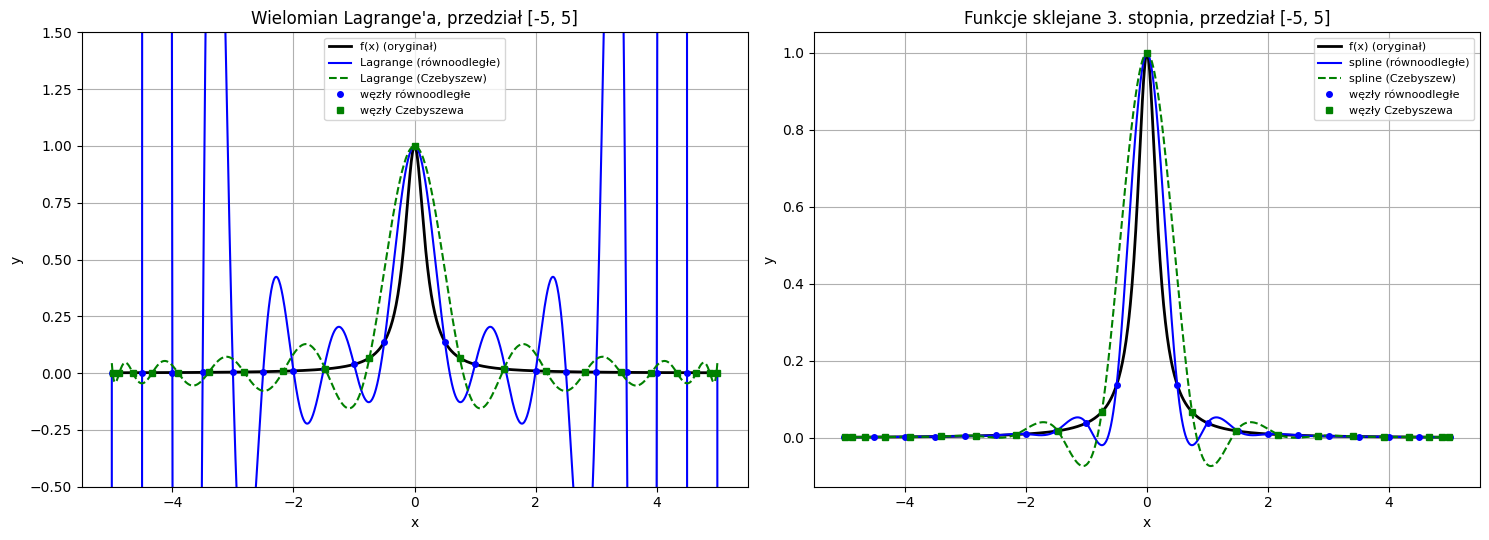

Przedział [-5, 5] — maksymalny błąd interpolacji:
  Lagrange równoodległe : 1.434e+03
  Lagrange Czebyszew    : 4.666e-01
  Spline   równoodległe : 2.754e-01
  Spline   Czebyszew    : 4.351e-01



In [4]:
from scipy.interpolate import lagrange, interp1d

# Funkcja Rungego
f = lambda x: 1.0 / (25.0 * x**2 + 1.0)

def chebyshev_nodes(n, a, b):
    """n węzłów Czebyszewa przeskalowanych na przedział [a, b]."""
    k = np.arange(n)
    x = np.cos((2 * k + 1) / (2 * n) * np.pi)   # węzły na [-1, 1]
    return 0.5 * (a + b) + 0.5 * (b - a) * x

N = 21
for (a, b) in [(-2, 2), (-5, 5)]:
    x_equi = np.linspace(a, b, N)
    x_cheb = np.sort(chebyshev_nodes(N, a, b))
    xx = np.linspace(a, b, 1000)

    # Interpolacja Lagrange'a
    L_equi = lagrange(x_equi, f(x_equi))
    L_cheb = lagrange(x_cheb, f(x_cheb))

    # Funkcje sklejane 3. stopnia (extrapolate, bo węzły Czebyszewa nie sięgają krańców)
    S_equi = interp1d(x_equi, f(x_equi), kind='cubic',
                      bounds_error=False, fill_value='extrapolate')
    S_cheb = interp1d(x_cheb, f(x_cheb), kind='cubic',
                      bounds_error=False, fill_value='extrapolate')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    # --- Lagrange ---
    axes[0].plot(xx, f(xx), 'k-', lw=2, label='f(x) (oryginał)')
    axes[0].plot(xx, L_equi(xx), 'b-', label='Lagrange (równoodległe)')
    axes[0].plot(xx, L_cheb(xx), 'g--', label='Lagrange (Czebyszew)')
    axes[0].plot(x_equi, f(x_equi), 'bo', markersize=4, label='węzły równoodległe')
    axes[0].plot(x_cheb, f(x_cheb), 'gs', markersize=4, label='węzły Czebyszewa')
    axes[0].set_title(f'Wielomian Lagrange\'a, przedział [{a}, {b}]')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].grid()
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(-0.5, 1.5)

    # --- Funkcje sklejane ---
    axes[1].plot(xx, f(xx), 'k-', lw=2, label='f(x) (oryginał)')
    axes[1].plot(xx, S_equi(xx), 'b-', label='spline (równoodległe)')
    axes[1].plot(xx, S_cheb(xx), 'g--', label='spline (Czebyszew)')
    axes[1].plot(x_equi, f(x_equi), 'bo', markersize=4, label='węzły równoodległe')
    axes[1].plot(x_cheb, f(x_cheb), 'gs', markersize=4, label='węzły Czebyszewa')
    axes[1].set_title(f'Funkcje sklejane 3. stopnia, przedział [{a}, {b}]')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].grid()
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f'Przedział [{a}, {b}] — maksymalny błąd interpolacji:')
    print(f'  Lagrange równoodległe : {np.max(np.abs(L_equi(xx) - f(xx))):.3e}')
    print(f'  Lagrange Czebyszew    : {np.max(np.abs(L_cheb(xx) - f(xx))):.3e}')
    print(f'  Spline   równoodległe : {np.max(np.abs(S_equi(xx) - f(xx))):.3e}')
    print(f'  Spline   Czebyszew    : {np.max(np.abs(S_cheb(xx) - f(xx))):.3e}\n')


**Wnioski (Zadanie 3 — efekt Rungego):**

- Interpolacja wielomianem Lagrange'a w **węzłach równoodległych** prowadzi do silnych oscylacji na krańcach przedziału (**efekt Rungego**) — błąd rośnie wykładniczo wraz z odległością od środka i z liczbą węzłów. Na przedziale $[-5,5]$ zjawisko jest jeszcze drastyczniejsze.
- Zastosowanie **węzłów Czebyszewa** (gęstszych przy brzegach) niemal całkowicie eliminuje oscylacje wielomianu Lagrange'a — błąd maleje o kilka rzędów wielkości.
- **Funkcje sklejane 3. stopnia** są odporne na efekt Rungego niezależnie od rozmieszczenia węzłów, ponieważ są wielomianami niskiego stopnia sklejanymi lokalnie — dają najlepsze i najbardziej stabilne przybliżenie.
- Wniosek praktyczny: dla równoodległych danych nie należy stosować jednego wielomianu wysokiego stopnia — lepsze są funkcje sklejane lub odpowiedni dobór węzłów (Czebyszew).


***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

Kierowca minął fotoradar w chwili t = 2.2758 s
Prędkość w tym momencie: v = 21.6819 m/s = 78.05 km/h


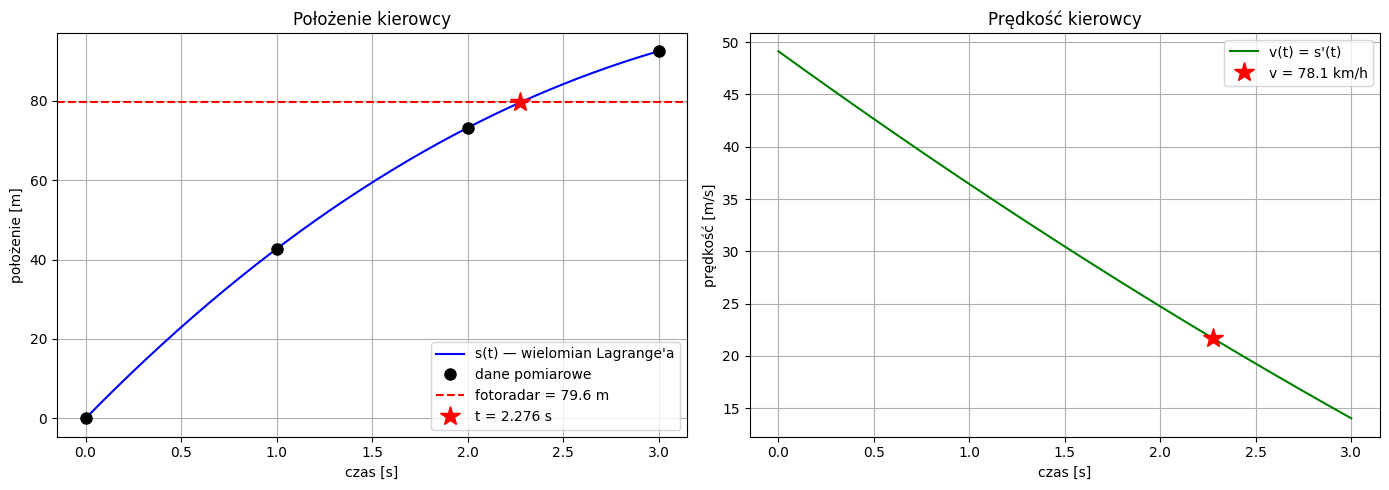

In [5]:
# Dane pomiarowe: czas [s] i położenie [m]
t = np.array([0.0, 1.0, 2.0, 3.0])
s = np.array([0.0, 42.7, 73.2, 92.5])
s_radar = 79.6  # położenie fotoradaru [m]

# Wielomian interpolacyjny położenia s(t)
S = lagrange(t, s)

# Szukamy chwili t, w której s(t) = 79.6, czyli pierwiastka g(t) = s(t) - 79.6.
# Wykorzystujemy metodę bisekcji z laboratorium 3.
g = lambda tt: S(tt) - s_radar

def bisection(g, a, b, tol=1e-10, max_iter=200):
    if g(a) * g(b) > 0:
        raise ValueError('Brak zmiany znaku na przedziale')
    for _ in range(max_iter):
        c = 0.5 * (a + b)
        if abs(g(c)) < tol or 0.5 * (b - a) < tol:
            return c
        if g(a) * g(c) < 0:
            b = c
        else:
            a = c
    return c

# Z danych: s(2)=73.2 < 79.6 < 92.5=s(3), więc pierwiastek leży w [2, 3]
t_radar = bisection(g, 2.0, 3.0)

# Prędkość = pochodna położenia po czasie: v(t) = s'(t)
dS = np.polyder(S)
v_radar = np.polyval(dS, t_radar)

print(f'Kierowca minął fotoradar w chwili t = {t_radar:.4f} s')
print(f'Prędkość w tym momencie: v = {v_radar:.4f} m/s = {v_radar * 3.6:.2f} km/h')

# Wykres
xx = np.linspace(0, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xx, S(xx), 'b-', label='s(t) — wielomian Lagrange\'a')
axes[0].plot(t, s, 'ko', markersize=8, label='dane pomiarowe')
axes[0].axhline(s_radar, color='r', ls='--', label=f'fotoradar = {s_radar} m')
axes[0].plot(t_radar, s_radar, 'r*', markersize=15, label=f't = {t_radar:.3f} s')
axes[0].set_xlabel('czas [s]'); axes[0].set_ylabel('położenie [m]')
axes[0].set_title('Położenie kierowcy'); axes[0].legend(); axes[0].grid()

axes[1].plot(xx, np.polyval(dS, xx), 'g-', label="v(t) = s'(t)")
axes[1].plot(t_radar, v_radar, 'r*', markersize=15, label=f'v = {v_radar*3.6:.1f} km/h')
axes[1].set_xlabel('czas [s]'); axes[1].set_ylabel('prędkość [m/s]')
axes[1].set_title('Prędkość kierowcy'); axes[1].legend(); axes[1].grid()
plt.tight_layout()
plt.show()


**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.


In [6]:
from functools import reduce
import operator

def lagrange_interpolator(xs, ys):
    """Zwraca wielomian interpolacyjny Lagrange'a jako obiekt typu funkcja.

    Wzór:  L(x) = sum_i  y_i * prod_{j != i} (x - x_j) / (x_i - x_j)
    Realizacja w stylu funkcyjnym z użyciem lambda, map/reduce i operator.
    """
    n = len(xs)

    def basis(i):
        # i-ty wielomian bazowy Lagrange'a l_i(x)
        return lambda x: reduce(
            operator.mul,
            (((x - xs[j]) / (xs[i] - xs[j])) for j in range(n) if j != i),
            1.0,
        )

    bases = [basis(i) for i in range(n)]
    return lambda x: reduce(operator.add, (ys[i] * bases[i](x) for i in range(n)), 0.0)

# Test na danych z Zadania 2 (pierwsza funkcja)
L = lagrange_interpolator(x1, y1)
print(f'L(0.43) = {L(0.43):.6f}   (scipy.lagrange: {L1(0.43):.6f})')

# Sprawdzenie zgodności na całym przedziale
xx = np.linspace(x1.min(), x1.max(), 50)
print(f'Maksymalna różnica względem scipy.interpolate.lagrange: '
      f'{np.max(np.abs([L(x) for x in xx] - L1(xx))):.2e}')


L(0.43) = 2.360605   (scipy.lagrange: 2.360605)
Maksymalna różnica względem scipy.interpolate.lagrange: 5.33e-15
